In [1]:
"""Dynamic Ray Tracing with Sionna RT and DeepMIMO."""

'Dynamic Ray Tracing with Sionna RT and DeepMIMO.'

# Dynamic Ray Tracing

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepMIMO/DeepMIMO/blob/main/docs/applications/5_dynamic_rt.py)
&nbsp;
[![GitHub](https://img.shields.io/badge/Open_on-GitHub-181717?logo=github&style=for-the-badge)](https://github.com/DeepMIMO/DeepMIMO/blob/main/docs/applications/5_dynamic_rt.py)

---

> **You probably don't need this notebook.**
>
> Dynamic ray tracing — running the ray tracer once per time snapshot — is
> computationally expensive and almost never necessary.  For the vast majority
> of mobility scenarios (channel prediction, beam tracking, Doppler simulation,
> channel aging), **[Tutorial 5: Doppler & Mobility](../tutorials/5_doppler_mobility.ipynb)**
> gives you everything you need at a tiny fraction of the cost: sample
> consecutive static positions along a trajectory and apply Doppler shifts
> afterwards.  You get realistic time-varying channels without re-running the
> ray tracer at all.
>
> **Use dynamic RT only when scene geometry itself changes between time steps** —
> for example, a moving vehicle that physically blocks signal paths that were
> previously open, or a transmitter that moves so far that the set of
> interacting surfaces is fundamentally different.

---

## What This Notebook Covers

This notebook demonstrates the rare case where you genuinely need dynamic RT:
a **drone base-station (TX) flying along a street canyon** while a set of
ground-level UEs (RX) remains fixed.  Because the drone is far from the
static TX positions used in Tutorial 5's scenario, the ray-traced paths
differ substantially between snapshots — a case where re-running the ray
tracer is justified.

**Steps:**
1. Load Sionna's built-in street-canyon scene
2. Ray trace **N snapshots** — one per drone position
3. Export and convert each snapshot to a DeepMIMO scenario
4. Assemble snapshots into a `DynamicDataset`
5. Apply timestamps, inspect TX velocity, and visualise how paths change

**Requirements:**
```bash
pip install 'deepmimo[sionna]'
```

In [2]:
%pip install 'deepmimo[sionna]'  # uncomment if not installed

/home/joao/DeepMIMO/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


## Imports

In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sionna.rt as sionna_rt
from sionna.rt import Camera, PathSolver, PlanarArray, Receiver, Transmitter

import deepmimo as dm
from deepmimo.datasets.dataset import DynamicDataset
from deepmimo.exporters.sionna_exporter import sionna_exporter

## Configuration

In [4]:
CARRIER_FREQ = 3.5e9  # Hz

# Drone trajectory: moves along the x-axis above the street
N_SNAPSHOTS = 4
DRONE_HEIGHT = 15.0  # metres above ground
DRONE_X_POSITIONS = [float(x) for x in np.linspace(-30.0, 30.0, N_SNAPSHOTS)]  # metres

# Fixed ground-level UEs
UE_POSITIONS = [
    [-15.0, 3.0, 1.5],
    [0.0, 3.0, 1.5],
    [15.0, 3.0, 1.5],
    [0.0, -3.0, 1.5],
]

# Ray-tracing settings (keep shallow for speed)
RT_PARAMS = {
    "max_depth": 2,
    "los": True,
    "specular_reflection": True,
    "diffuse_reflection": False,
    "refraction": False,
    "samples_per_src": 1_000_000,
}

# Time between consecutive drone snapshots
TIME_DELTA = 0.5  # seconds

# Output folder — reused across runs
WORK_DIR = Path.home() / ".cache" / "deepmimo" / "dynamic_rt_demo"
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Drone x positions: {DRONE_X_POSITIONS}")
print(f"Snapshots: {N_SNAPSHOTS}  |  Time delta: {TIME_DELTA} s")

Drone x positions: [-30.0, -10.0, 10.0, 30.0]
Snapshots: 4  |  Time delta: 0.5 s


## Build the Scene

`simple_street_canyon_with_cars` provides a realistic urban cross-section:
two parallel building blocks, parked cars on the kerbs, and an open street.
The drone (TX) is placed above the centreline; UEs are at street level.

In [5]:
scene = sionna_rt.load_scene(sionna_rt.scene.simple_street_canyon_with_cars)
scene.frequency = CARRIER_FREQ

single_ant = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)
scene.tx_array = single_ant
scene.rx_array = single_ant

# Add fixed UEs
for i, pos in enumerate(UE_POSITIONS):
    scene.add(Receiver(f"rx_{i}", position=pos))

# Add drone TX at the first snapshot position
drone = Transmitter("tx_0", position=[DRONE_X_POSITIONS[0], 0.0, DRONE_HEIGHT])
scene.add(drone)

print(f"Scene loaded: {len(scene.objects)} objects")
print(f"UEs: {len(UE_POSITIONS)}  |  TX: drone at height {DRONE_HEIGHT} m")

Scene loaded: 6 objects
UEs: 4  |  TX: drone at height 15.0 m


## Visualise the Scene (Snapshot 0)

Before running any ray tracing, render the scene to confirm the geometry.
The drone (red triangle) starts at one end of the street.

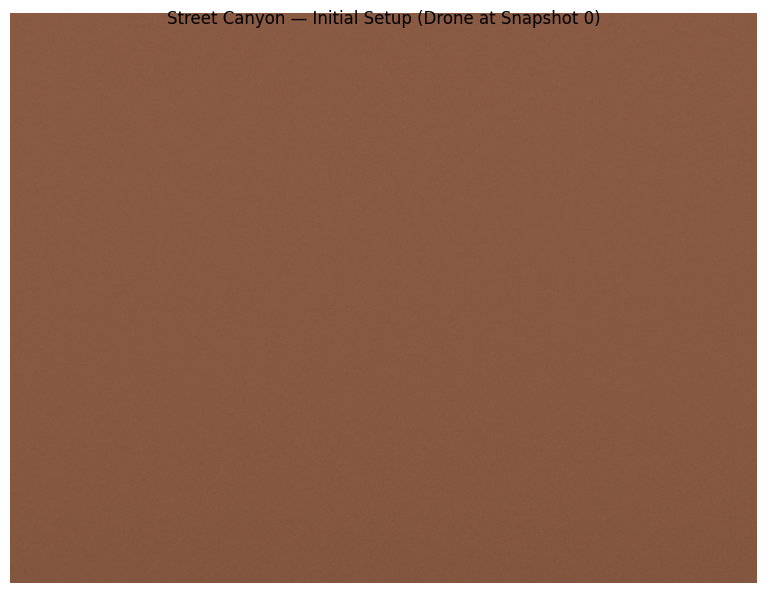

In [6]:
cam = Camera(position=[0.0, -60.0, 40.0], look_at=[0.0, 0.0, 5.0])
fig = scene.render(camera=cam, show_devices=True)
fig.suptitle("Street Canyon — Initial Setup (Drone at Snapshot 0)")
plt.show()

## Run Ray Tracing for Each Snapshot

For each drone position we:
1. Update `drone.position`
2. Run `PathSolver`
3. Export to a per-snapshot folder with `sionna_exporter`
4. Convert immediately to a DeepMIMO scenario with `dm.convert`

Each snapshot is an independent ray-tracing run.  The set of interacting
surfaces, path delays, and angles all change as the drone moves — which is
exactly why dynamic RT is needed here rather than post-hoc Doppler.

Determining converter...
Using Sionna RT converter
converting from sionna RT


Processing receivers for TX 0, Ant 0:   0%|          | 0/4 [00:00<?, ?it/s]

Processing receivers for TX 0, Ant 0: 100%|██████████| 4/4 [00:00<00:00, 5251.08it/s]

Snapshot 0: drone x=-30 m  →  16 valid paths
Determining converter...
Using Sionna RT converter
converting from sionna RT


Processing receivers for TX 0, Ant 0:   0%|          | 0/4 [00:00<?, ?it/s]

...

Processing receivers for TX 0, Ant 0: 100%|██████████| 4/4 [00:00<00:00, 4864.37it/s]

Snapshot 2: drone x=+10 m  →  29 valid paths
Determining converter...
Using Sionna RT converter
converting from sionna RT


Processing receivers for TX 0, Ant 0:   0%|          | 0/4 [00:00<?, ?it/s]

Processing receivers for TX 0, Ant 0: 100%|██████████| 4/4 [00:00<00:00, 5656.51it/s]

Snapshot 3: drone x=+30 m  →  15 valid paths

Converted 4 snapshots.


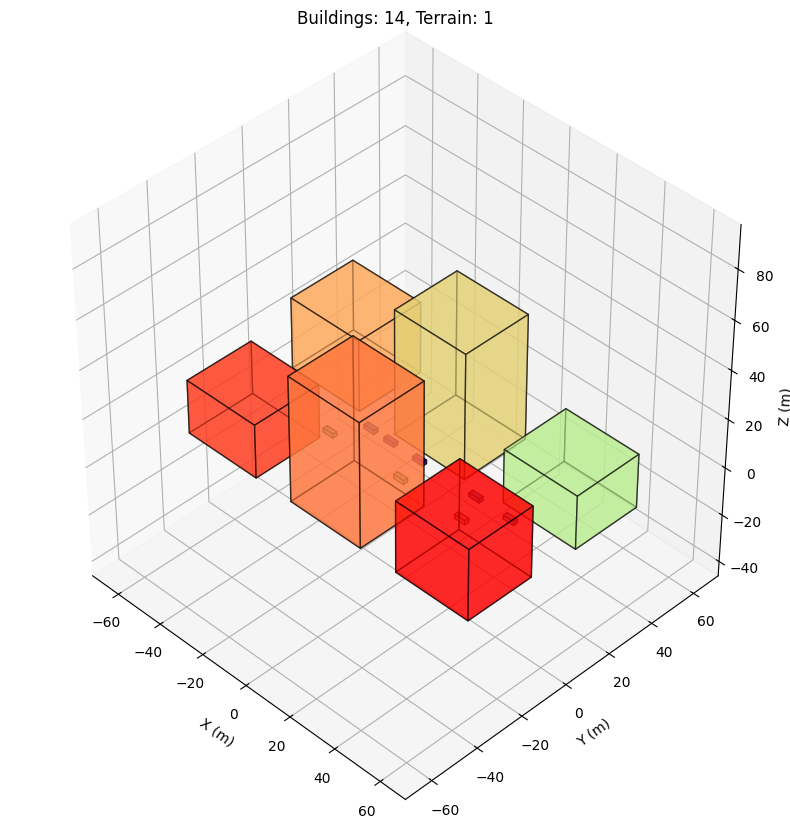

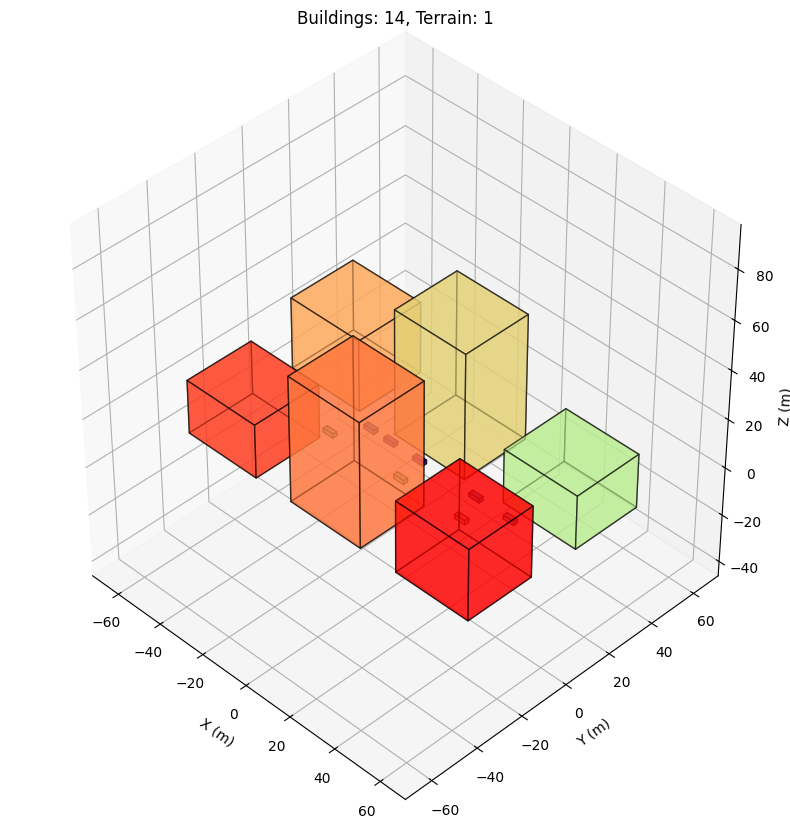

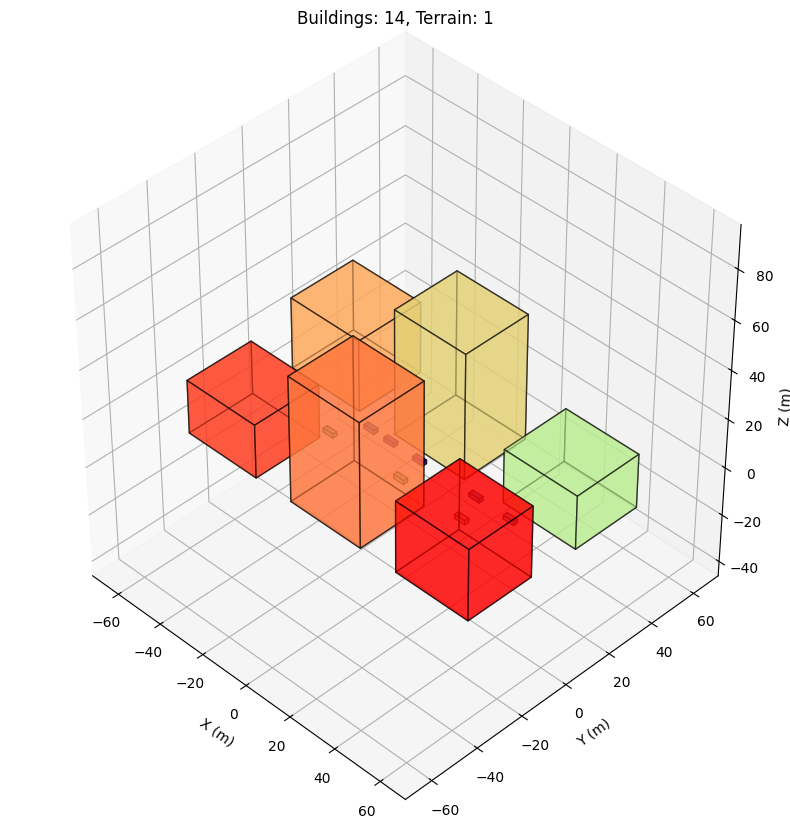

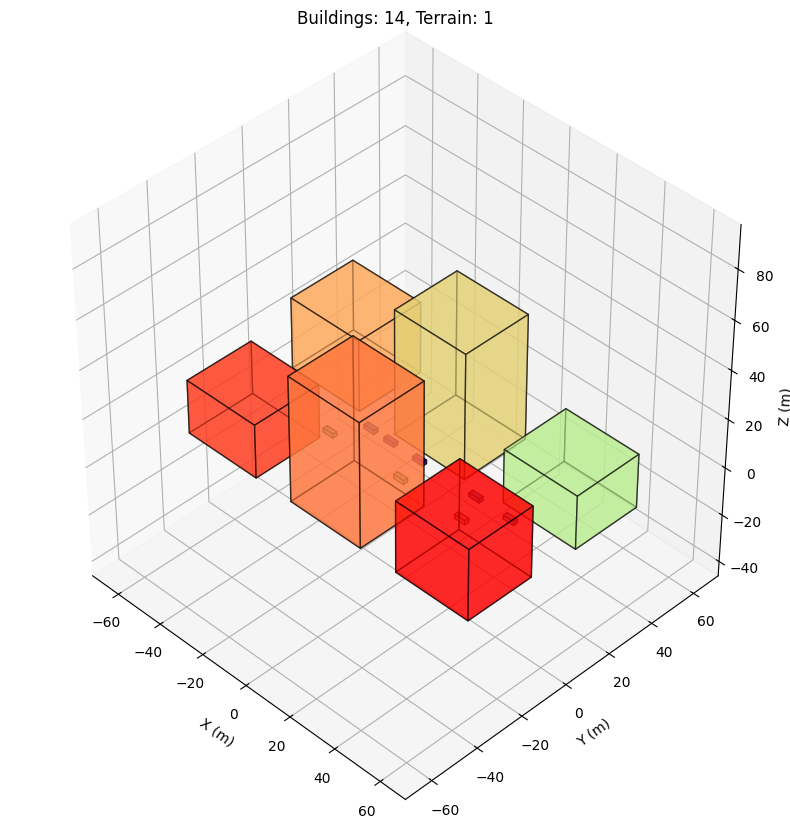

In [7]:
solver = PathSolver()
scenario_names: list[str] = []

for snap_idx, drone_x in enumerate(DRONE_X_POSITIONS):
    drone.position = [drone_x, 0.0, DRONE_HEIGHT]

    # Ray trace
    paths = solver(scene=scene, **RT_PARAMS)

    # Export
    snap_folder = str(WORK_DIR / f"snapshot_{snap_idx}")
    sionna_exporter(scene, paths, RT_PARAMS, snap_folder)

    # Convert to DeepMIMO
    scen_name = f"dynamic_rt_demo_snap{snap_idx}"
    dm.convert(snap_folder, scenario_name=scen_name, overwrite=True)
    scenario_names.append(scen_name)

    n_valid = int((paths.tau.numpy() > 0).sum())
    print(f"Snapshot {snap_idx}: drone x={drone_x:+.0f} m  →  {n_valid} valid paths")

print(f"\nConverted {len(scenario_names)} snapshots.")

## Assemble a `DynamicDataset`

Load each snapshot individually, then wrap them in a `DynamicDataset` —
the DeepMIMO container for time-ordered scene snapshots.

In [8]:
snapshots = [dm.load(name) for name in scenario_names]
dyn = DynamicDataset(snapshots, name="dynamic_rt_demo")

print(f"Dynamic dataset: {dyn.n_scenes} scenes")
for i, snap in enumerate(dyn.datasets):
    print(f"  Scene {i}: TX={snap.tx_pos.flatten()}, n_ue={snap.n_ue}")

Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 4)
Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 4)
Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 4)
Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 4)
Dynamic dataset: 4 scenes
  Scene 0: TX=[-30.   0.  15.], n_ue=4
  Scene 1: TX=[-10.   0.  15.], n_ue=4
  Scene 2: TX=[10.  0. 15.], n_ue=4
  Scene 3: TX=[30.  0. 15.], n_ue=4


## Apply Timestamps → Velocities

Timestamps tell DeepMIMO the real time elapsed between snapshots.  From
those and the TX position differences it derives TX/RX velocities, which
can then be used with `ch_params.doppler = True` to compute time-varying
channels (see **Tutorial 5** for the channel-generation step).

In [9]:
dyn.set_timestamps(TIME_DELTA)

print(f"Timestamps: {dyn.timestamps} s")
print(f"Drone speed: {np.linalg.norm(dyn.tx_vel[0]):.1f} m/s "
      f"({np.linalg.norm(dyn.tx_vel[0]) * 3.6:.1f} km/h)")

Timestamps: [0.  0.5 1.  1.5] s
Drone speed: 40.0 m/s (144.0 km/h)


## Visualise Path Changes Across Snapshots

The most informative view of a dynamic dataset is how propagation paths
evolve as the drone moves.  Each subplot shows the rays from TX to a fixed
UE for one snapshot — notice how the set of active paths, their directions,
and their delays shift across scenes.

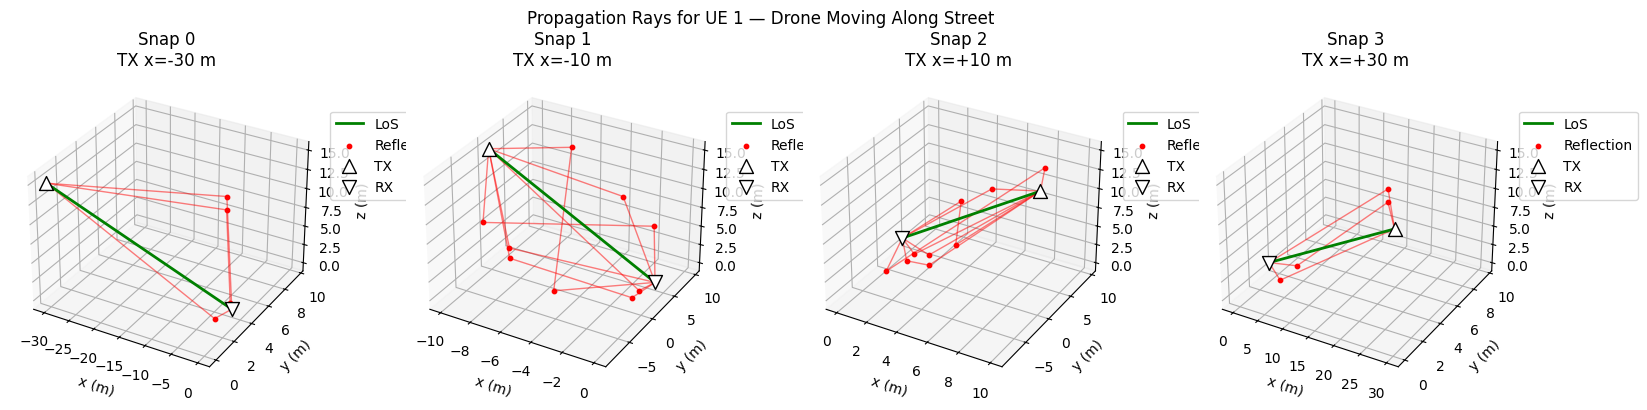

In [10]:
UE_IDX = 1  # UE in the centre of the street

fig, axes = plt.subplots(1, N_SNAPSHOTS, figsize=(4 * N_SNAPSHOTS, 4),
                         subplot_kw={"projection": "3d"})
for snap_idx, ax in enumerate(axes):
    snap = dyn[snap_idx]
    snap.plot_rays(UE_IDX, ax=ax)
    ax.set_title(f"Snap {snap_idx}\nTX x={DRONE_X_POSITIONS[snap_idx]:+.0f} m")
fig.suptitle(f"Propagation Rays for UE {UE_IDX} — Drone Moving Along Street",
             fontsize=12)
plt.tight_layout()
plt.show()

## Power Across Snapshots

Plot the peak received power for each UE as the drone flies overhead.
The coverage pattern shifts as LoS geometry and reflection angles change.

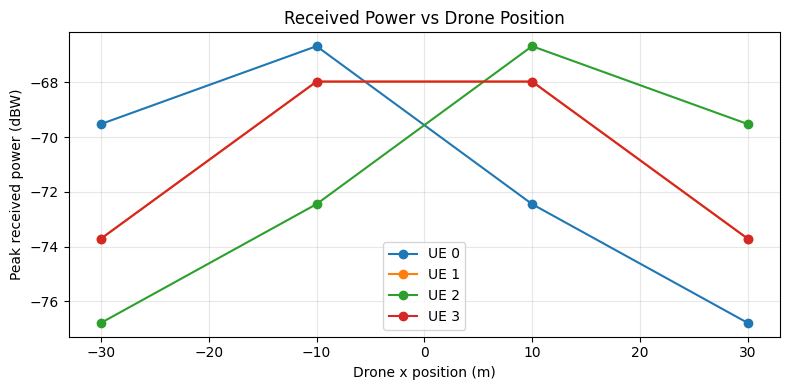

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

for ue_idx in range(len(UE_POSITIONS)):
    peak_power = []
    for snap in dyn.datasets:
        pwr = snap.power[ue_idx]
        MIN_POWER_DBW = -200
        valid = pwr[np.isfinite(pwr) & (pwr > MIN_POWER_DBW)]
        peak_power.append(float(np.max(valid)) if valid.size > 0 else float("nan"))
    ax.plot(DRONE_X_POSITIONS, peak_power, "o-", label=f"UE {ue_idx}")

ax.set_xlabel("Drone x position (m)")
ax.set_ylabel("Peak received power (dBW)")
ax.set_title("Received Power vs Drone Position")
ax.legend()
ax.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Step | Tool | Output |
|------|------|--------|
| 1. Load scene | `sionna_rt.load_scene` | `Scene` with street canyon |
| 2. Move TX, ray trace | `PathSolver` x N | `Paths` per snapshot |
| 3. Export | `sionna_exporter` | `.pkl` files per snapshot |
| 4. Convert | `dm.convert` | DeepMIMO scenario per snapshot |
| 5. Assemble | `DynamicDataset` | Time-ordered scene sequence |
| 6. Timestamps | `dyn.set_timestamps` | TX/RX velocities derived |

### When to Use Dynamic RT vs Tutorial 5

| Scenario | Use |
|----------|-----|
| User moves within a static environment | **[Tutorial 5](../tutorials/5_doppler_mobility.ipynb)** |  # noqa: E501
| TX moves far enough to hit different surfaces | **This notebook** |
| Moving obstacle blocks/opens paths (e.g. truck) | **This notebook** |
| Many users, many trajectories, large-scale dataset | **[Batch Pipeline](../resources/batch_pipeline.md)** |  # noqa: E501

The rule of thumb: if the **geometry of the scene** changes between time steps
in a way that fundamentally alters which surfaces interact with the signal,
you need dynamic RT.  Otherwise, Tutorial 5's Doppler approach is both faster
and equally accurate.